In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
cols = ['area','perimeter','compactness','length','width','aysmetry','groove','class']
df = pd.read_csv('seeds_dataset.txt',names=cols,sep='\s+')

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ENVY\AppData\Local\Temp\ipykernel_16184\3383648719.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('seeds_dataset.txt',names=cols,sep='\s+')


In [3]:
df.head()

,area,perimeter,compactness,length,width,aysmetry,groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


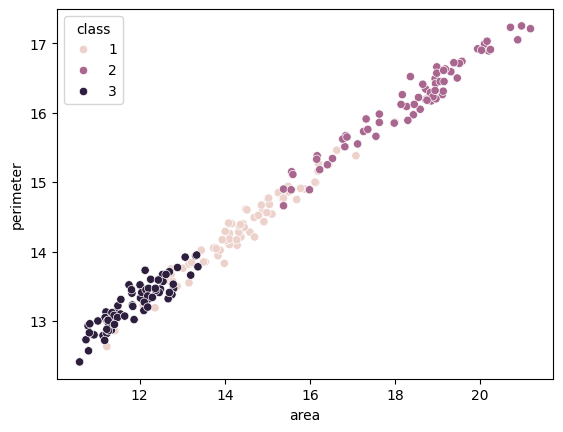

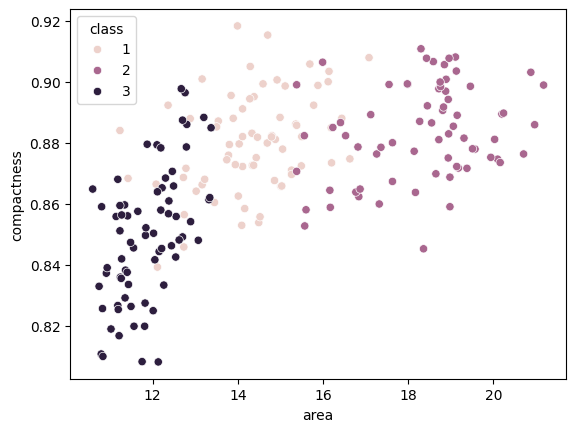

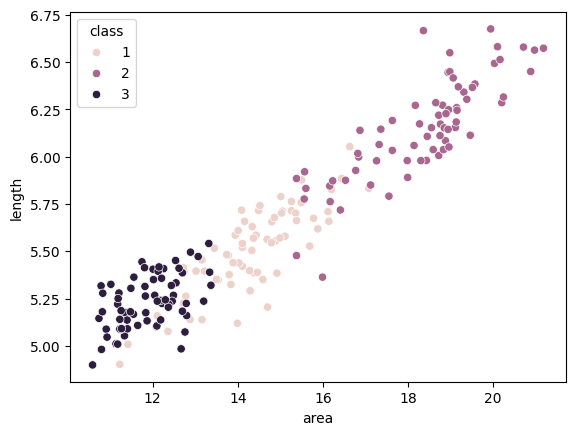

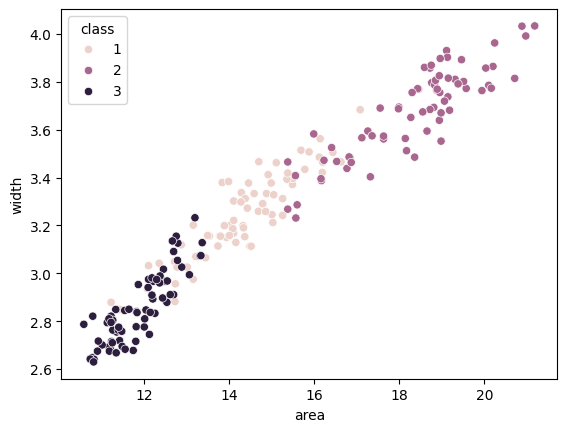

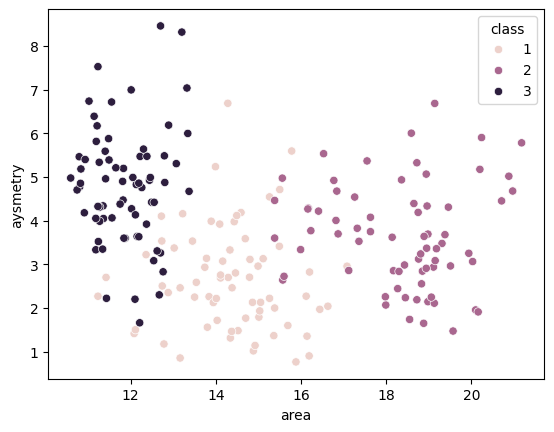

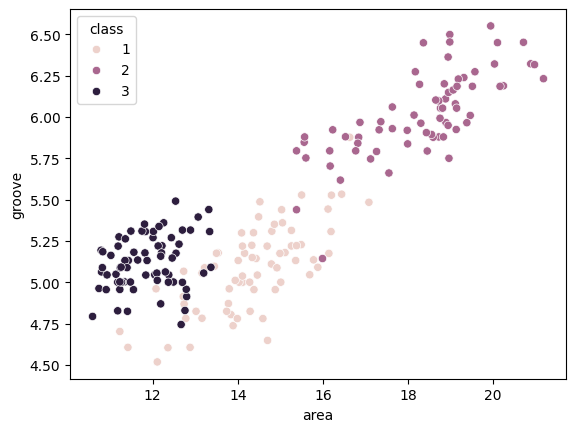

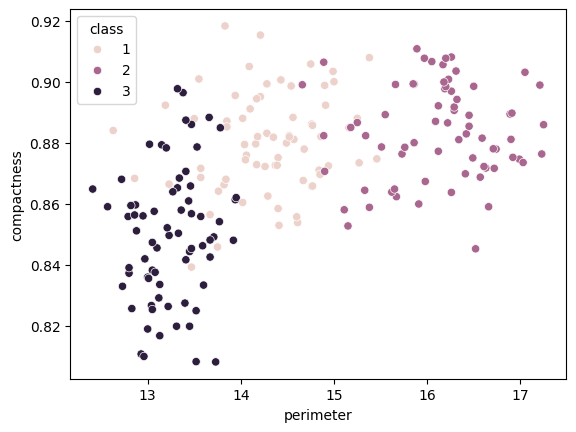

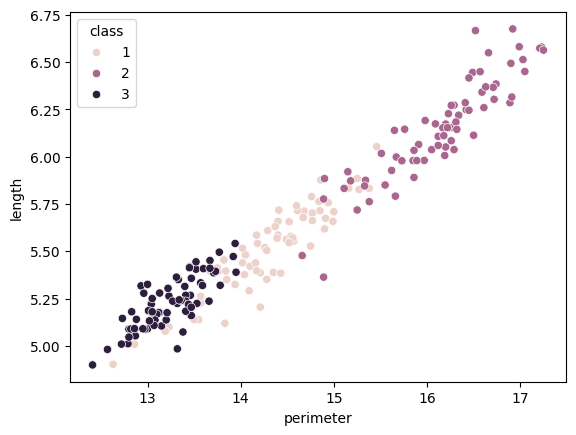

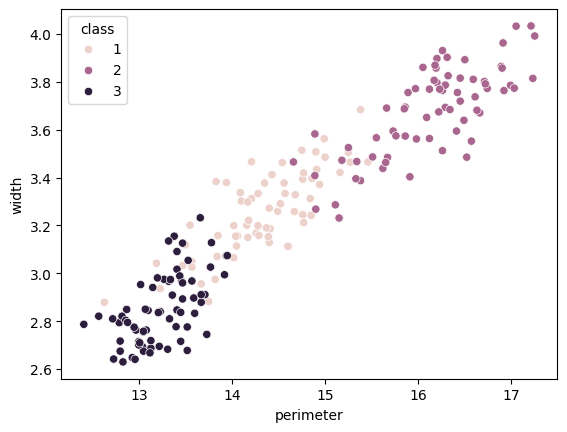

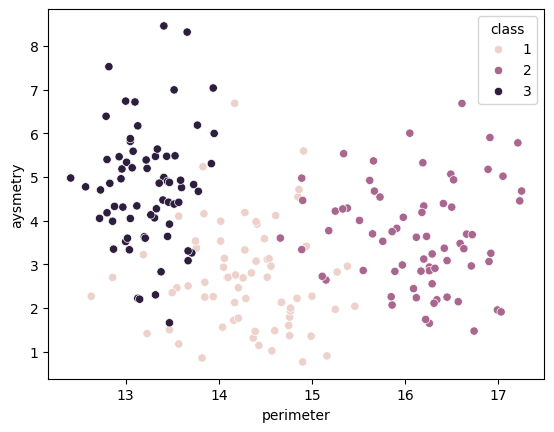

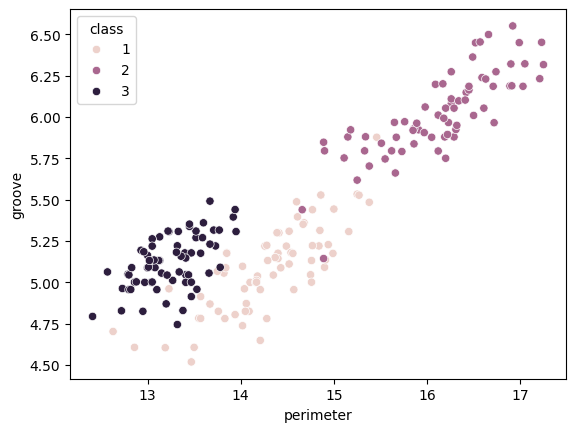

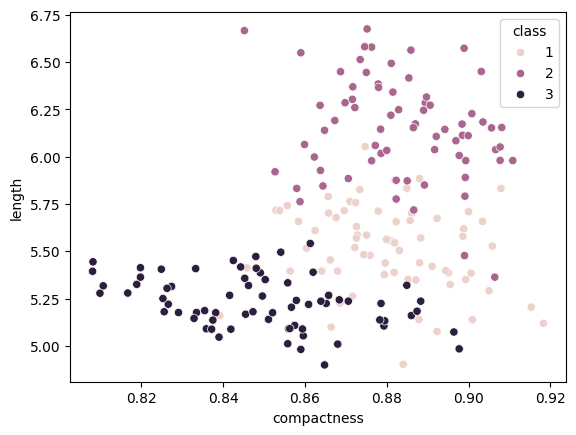

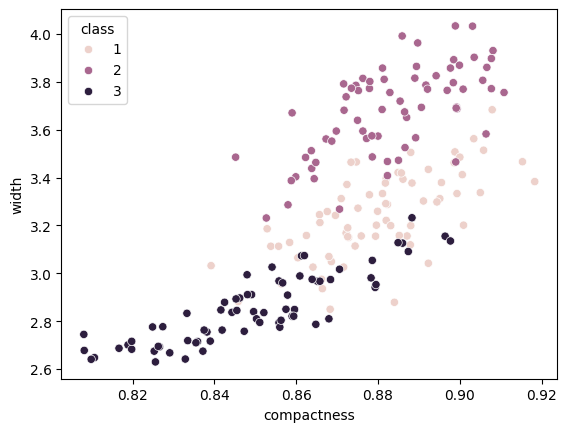

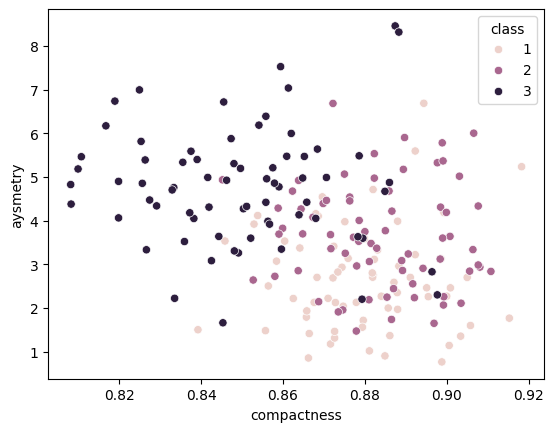

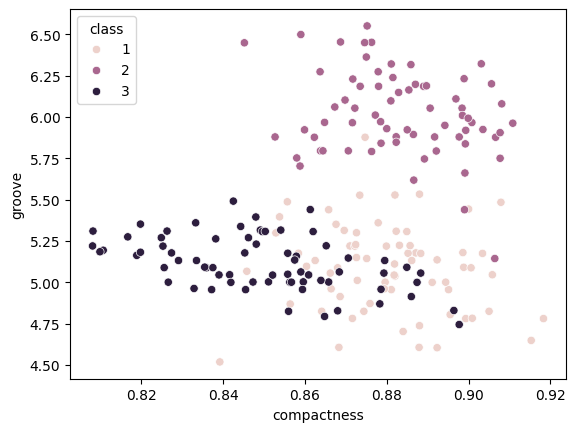

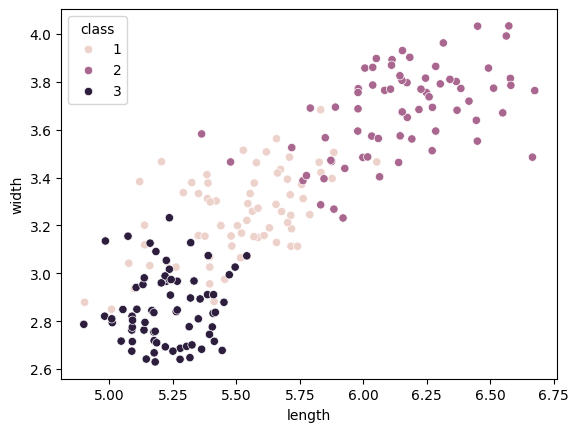

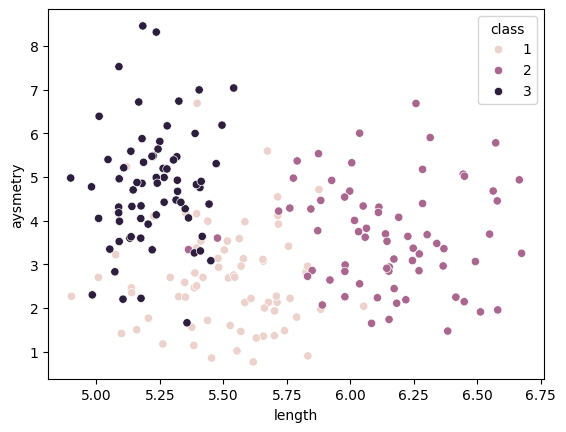

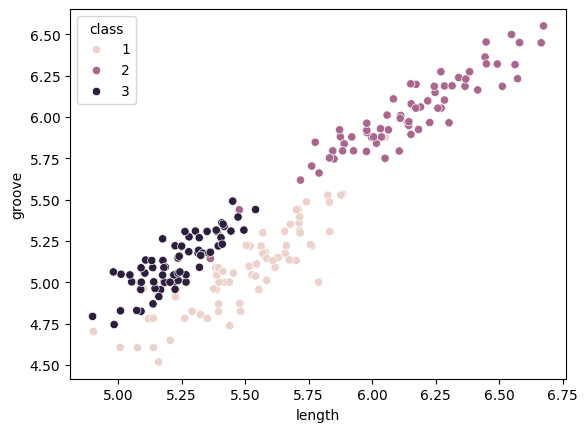

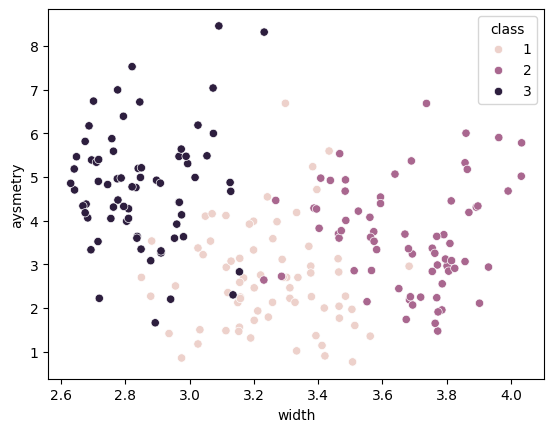

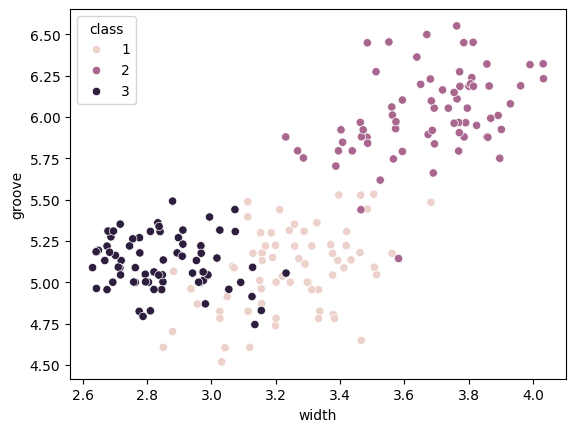

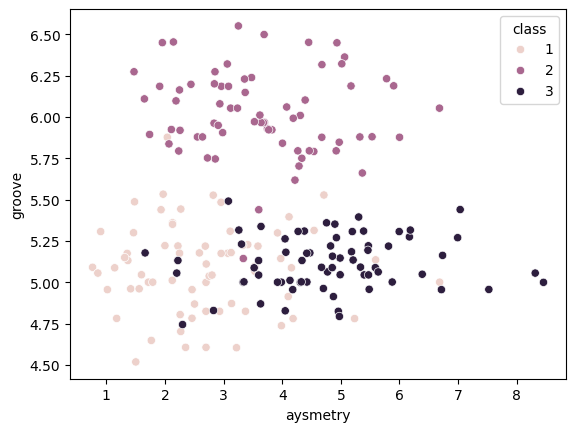

In [4]:
for i in range(len(cols)-1):
  for j in range(i+1,len(cols)-1):
    x_label = cols[i]
    y_label = cols[j]
    sns.scatterplot(x=x_label,y=y_label,hue='class',data=df)
    plt.show()

In [5]:
from sklearn.cluster import KMeans

In [6]:
x = 'compactness'
y = 'aysmetry'
X = df[[x,y]].values

In [7]:
kmeans = KMeans(n_clusters=3).fit(X)

In [8]:
clusters = kmeans.labels_

In [9]:
cluster_df = pd.DataFrame(np.hstack((X,clusters.reshape(-1,1))),columns=[x,y,'class'])

[]

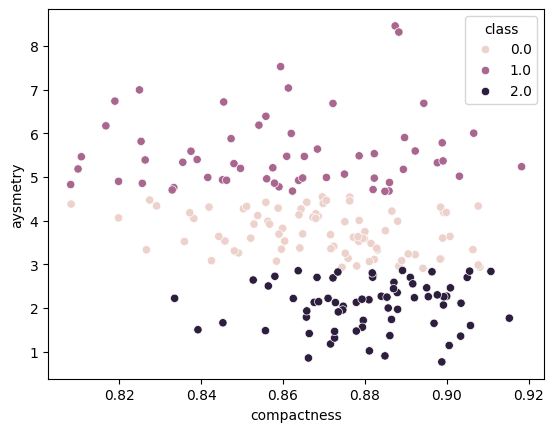

In [10]:
#Kmeans Classes
sns.scatterplot(x=x,y=y,hue='class',data=cluster_df)
plt.plot()

[]

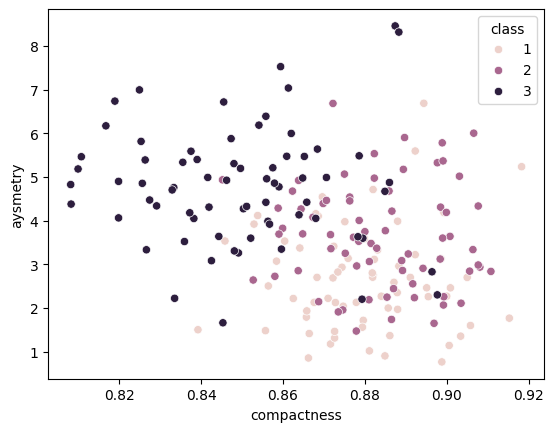

In [11]:
#Original Classes
sns.scatterplot(x=x,y=y,hue='class',data=df)
plt.plot()

In [12]:
X = df[cols[:-1]].values

In [13]:
kmeans = KMeans(n_clusters=3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X,kmeans.labels_.reshape(-1,1))),columns=df.columns)

[]

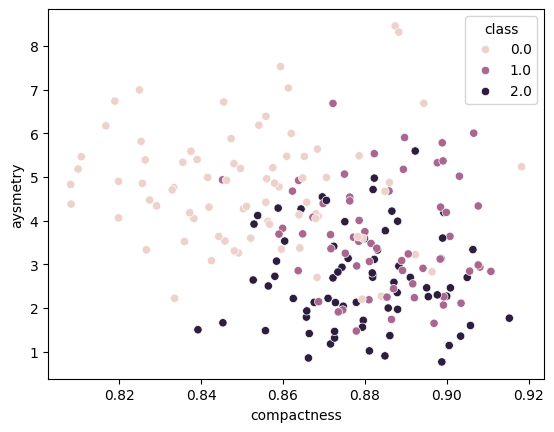

In [14]:
sns.scatterplot(x=x,y=y,hue='class',data=cluster_df)
plt.plot()

[]

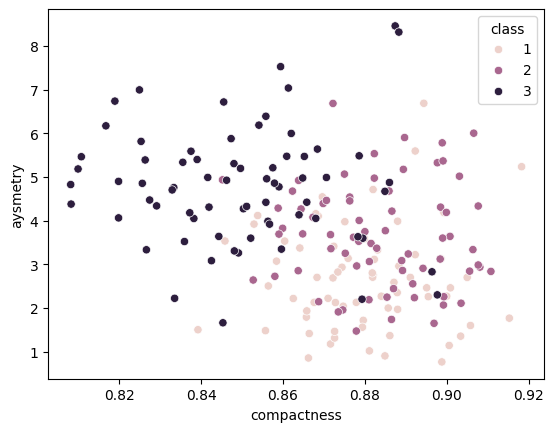

In [15]:
sns.scatterplot(x=x,y=y,hue='class',data=df)
plt.plot()

In [16]:
#PCA
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components=2)
transformed_x = pca.fit_transform(X)

In [18]:
X.shape

(210, 7)

In [19]:
transformed_x.shape

(210, 2)

In [20]:
transformed_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

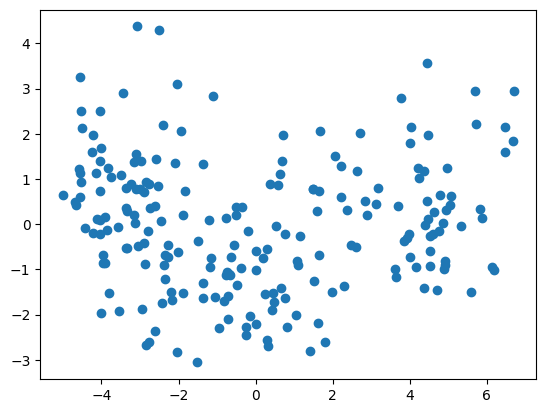

In [21]:
plt.scatter(transformed_x[:,0],transformed_x[:,1])
plt.show()

In [22]:
kmeans_pca_df  = pd.DataFrame(np.hstack((transformed_x,kmeans.labels_.reshape(-1,1))),columns=[ 'PCA1','PCA2','class'])

In [23]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x,df['class'].values.reshape(-1,1))),columns=[ 'PCA1','PCA2','class'])

[]

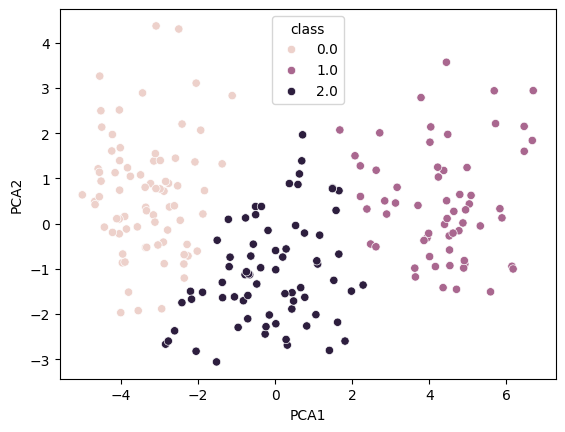

In [25]:
#Kmeans Classes
sns.scatterplot(x='PCA1',y='PCA2',hue='class',data=kmeans_pca_df)
plt.plot()

[]

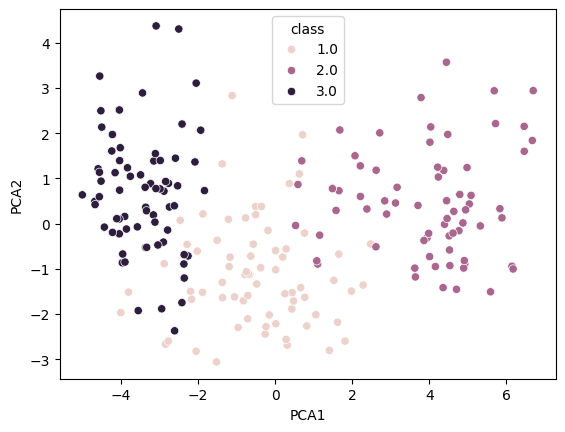

In [26]:
#Original Classes
sns.scatterplot(x='PCA1',y='PCA2',hue='class',data=truth_pca_df)
plt.plot()